### Import Library

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder, label_binarize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
import skfuzzy as fuzz
from collections import Counter
from scipy import stats
from scipy.stats import mode
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

### Simulation

In [17]:
# Load and prepare Iris data
iris = load_iris()
X = iris.data
y = iris.target
class_names = iris.target_names
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Standardize the features using training data statistics
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Perform K-nearest neighbors on TRAINING data
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

cluster_train = knn.predict(X_train_scaled)

print("Cluster:", np.unique(cluster_train))
cluster_test = knn.predict(X_test_scaled)

Cluster: [0 1 2]


In [18]:
cluster_to_class = {}

for cluster in np.unique(cluster_train):
    idx = np.where(cluster_train == cluster)
    majority = mode(y_train[idx], keepdims=True)[0][0]
    cluster_to_class[cluster] = majority

print(cluster_to_class)

{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}


In [19]:
y_pred_train = np.vectorize(cluster_to_class.get)(cluster_train)
y_pred_test = np.vectorize(cluster_to_class.get)(cluster_test)

In [20]:
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"\nTrain Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")


Train Accuracy : 0.9524
Test Accuracy  : 1.0000


In [21]:
report = classification_report(
    y_test,
    y_pred_test,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



<Figure size 600x500 with 0 Axes>

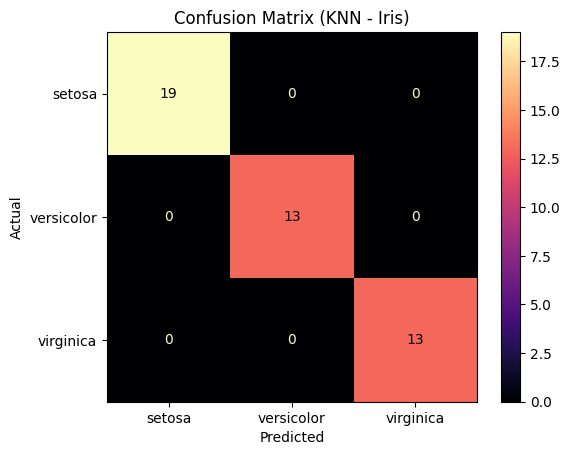

In [22]:
cm_test = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                            display_labels=['setosa', 'versicolor', 'virginica'])
disp.plot(cmap='magma', values_format='d')
#sns.heatmap(cm_test,
#            annot=True,
#            cmap="magma",
#            fmt="d")

plt.title("Confusion Matrix (KNN - Iris)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [23]:
hasil = pd.DataFrame(X_test_scaled[:,:2])
hasil.columns = ['Sepal length', 'Sepal width']
hasil = pd.concat([hasil, pd.Series(y_pred_test, name='Class')], axis=1)
hasil_centroids = hasil.groupby('Class')[['Sepal length', 'Sepal width']].mean()

centroids_original = hasil_centroids.copy()
# Inverse from this sample
centroids_original['Sepal length'] = (
    centroids_original['Sepal length'] * (7.9 - 4.3) + 4.3
)

centroids_original['Sepal width'] = (
    centroids_original['Sepal width'] * (4.4 - 2.0) + 2.0
)

print(centroids_original)


       Sepal length  Sepal width
Class                           
0          5.119195     3.647847
1          6.254751     2.981818
2          6.808597     3.023776


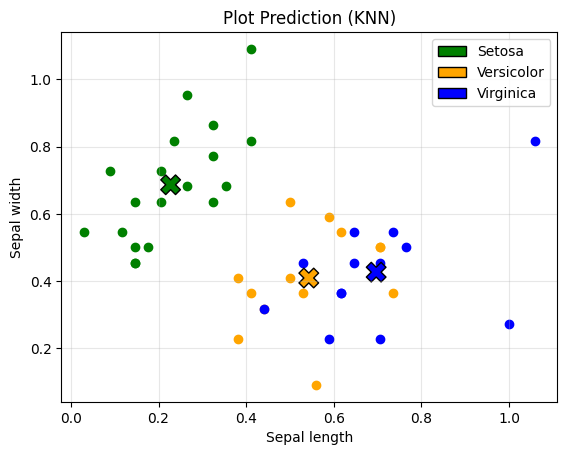

In [24]:
class_names = ['setosa', 'versicolor', 'virginica']
colors = ['green', 'orange', 'blue']
marker_colors = {1: 'green', 2: 'orange', 3: 'blue'}


for i, class_id in enumerate(sorted(np.unique(hasil["Class"]))):
    mask = hasil["Class"] == class_id
    plt.scatter(hasil[mask]['Sepal length'], hasil[mask]['Sepal width'], c=colors[i],
                label=f'{class_names[i]}')

# Plot centroids
plt.scatter(hasil_centroids['Sepal length'], hasil_centroids['Sepal width'], 
            c=[marker_colors[1], marker_colors[2], marker_colors[3]], marker='X', s=200, 
            edgecolors='black', linewidth=1)

# Add custom legend for centroids
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=marker_colors[1], edgecolor='black', label='Setosa'),
                   Patch(facecolor=marker_colors[2], edgecolor='black', label='Versicolor'),
                   Patch(facecolor=marker_colors[3], edgecolor='black', label='Virginica')]
plt.legend(handles=legend_elements)

plt.xlabel(f'Sepal length')
plt.ylabel(f'Sepal width')
plt.title('Plot Prediction (KNN)')
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
prob_test = knn.predict_proba(X_test_scaled)

AUC class 0: 1.0
AUC class 1: 1.0
AUC class 2: 1.0


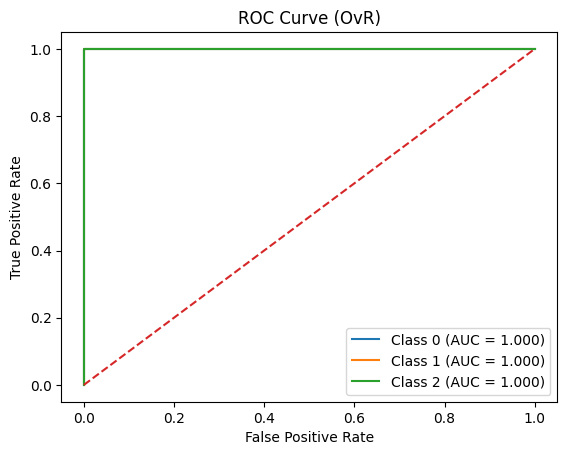

In [26]:
y_test_bin = label_binarize(y_pred_test, classes=[0,1,2])
n_classes = y_test_bin.shape[1]
plt.figure()
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], prob_test[:, i])
    roc_auc = auc(fpr, tpr)
    print(f"AUC class {i}:", roc_auc)
    plt.plot(fpr, tpr,
             label=f'Class {i} (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (OvR)")
plt.legend()
plt.show()

In [27]:
auc_ovr = roc_auc_score(y_test_bin, prob_test, multi_class="ovr")

print("Overall AUC (OvR):", auc_ovr)

Overall AUC (OvR): 1.0
